# Hopefully Final

## Packages

In [86]:
# Data Cleaning
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import colormaps

# Preprocessing & Feature Selection (sklearn)
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif

# Models
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

#Model Selection & Validation
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold

# Metrics
from sklearn.metrics import f1_score as sk_f1_score, recall_score as sk_recall_score
from sklearn.decomposition import PCA
from sklearn.metrics import(
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    recall_score,
    classification_report,
    confusion_matrix,
    average_precision_score,
    ConfusionMatrixDisplay
)

# Model Analysis & Interpretation
from sklearn.utils import resample
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import learning_curve
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    auc,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    ConfusionMatrixDisplay
)


## Data Cleaning

In [84]:
dataset=pd.read_csv("dataset.csv", index_col=0)
outcome=pd.read_csv("outcome.csv", index_col=0)

In [4]:
# combine sets
combined=dataset.join(outcome)

In [5]:
# how many missing values do we have?
combined.isna().sum(axis=1).sum()

np.int64(275)

In [6]:
# how many values are missing in each column?
combined.isna().sum(axis=0).sort_values(ascending=False)

BRCA_subtype    262
FGFR1OP2          5
RNF13             4
ATRX              4
PLIN3             0
               ... 
C16orf11          0
PLIN5             0
TSKS              0
IGFN1             0
PMM2              0
Length: 16384, dtype: int64

In [7]:
# remove all samples with missing values in the target variable
combined_clean=combined.dropna(subset=["BRCA_subtype"])

In [8]:
# check how many values are missing after removing the samples with missing subtype
remaining_nans = combined_clean.isna().sum()

In [9]:
# remove all samples with any missing value
combined_clean = combined_clean.dropna()

In [10]:
# control if there are still missing values
print(combined_clean.isna().sum().sum())

0


### Prove Imbalance

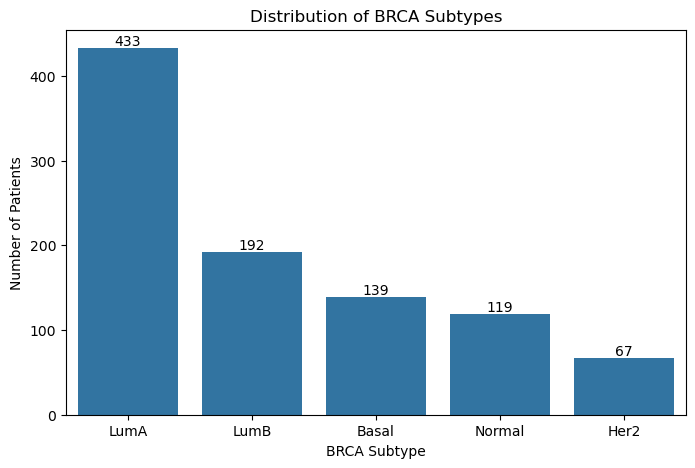

In [11]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=combined_clean, #because we have removed all samples with missing values, we can use the cleaned dataset for visualization
    x="BRCA_subtype",
    order=combined_clean["BRCA_subtype"].value_counts().index
)

# for number labels on top of the bars
for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribution of BRCA Subtypes")
plt.xlabel("BRCA Subtype")
plt.ylabel("Number of Patients")

plt.show()

### Check variances

In [12]:
# separate features and target variable
X = combined_clean.drop(columns=["BRCA_subtype"])
y = combined_clean["BRCA_subtype"]

In [13]:
# calculate variances of the features
variances = X.var()

In [14]:
# statistical summary of the variances
print(variances.describe())

count    16383.000000
mean         1.239637
std          1.742989
min          0.000000
25%          0.279232
50%          0.595600
75%          1.528650
max         37.376686
dtype: float64


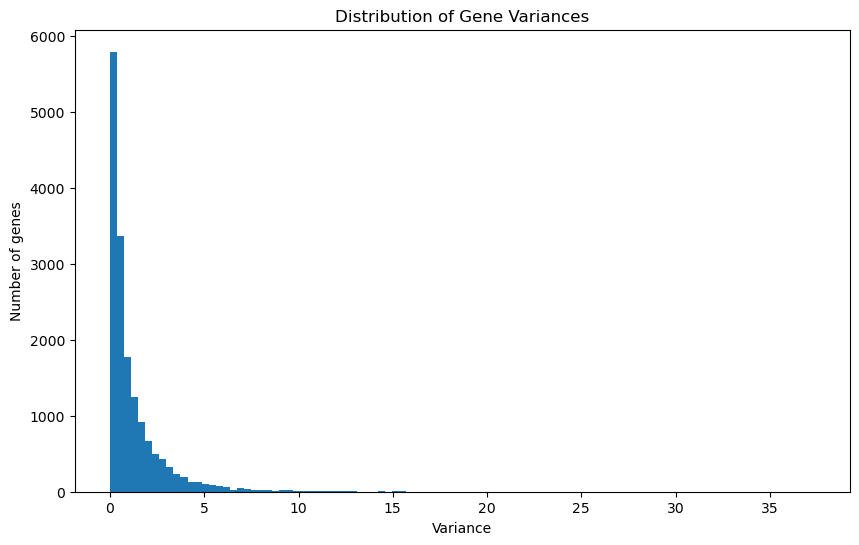

In [15]:
# Histogram of the variances
plt.figure(figsize=(10,6))
plt.hist(variances, bins=100)

plt.xlabel("Variance")
plt.ylabel("Number of genes")
plt.title("Distribution of Gene Variances")

plt.show()

In [16]:
overview = pd.DataFrame({
    "variable": combined_clean.columns,
    "dtype": combined_clean.dtypes.astype(str).values,
    "n_unique": [combined_clean[col].nunique() for col in combined_clean.columns]
})

display(overview)


,variable,dtype,n_unique
0,ARHGEF10L,float64,931
1,HIF3A,float64,911
2,RNF17,float64,219
3,RNF10,float64,906
4,RNF11,float64,925
...,...,...,...
16379,HCG27,float64,934
16380,CYP2A13,float64,342
16381,CCR10,float64,937
16382,KDM4D,float64,932


In [17]:
# Check the standard deviation of the features
gene_std = combined_clean.drop(columns="BRCA_subtype").std()
gene_std.sort_values().head(20)

# Output=0: no variation --> all patients have exactly the same value for this gene --> no helpful information

SNORD113-4     0.0
TXNDC8         0.0
RBMY1A3P       0.0
SNORD88B       0.0
TTTY3B         0.0
SNORD115-2     0.0
SNORD115-3     0.0
SNORD116-13    0.0
TTTY6B         0.0
DAZ4           0.0
SNORD60        0.0
SNORD115-11    0.0
SNORD44        0.0
TSSK2          0.0
LOC653545      0.0
SNORD105       0.0
SNORD91A       0.0
SNAR-D         0.0
SNORA11C       0.0
SNORD115-16    0.0
dtype: float64

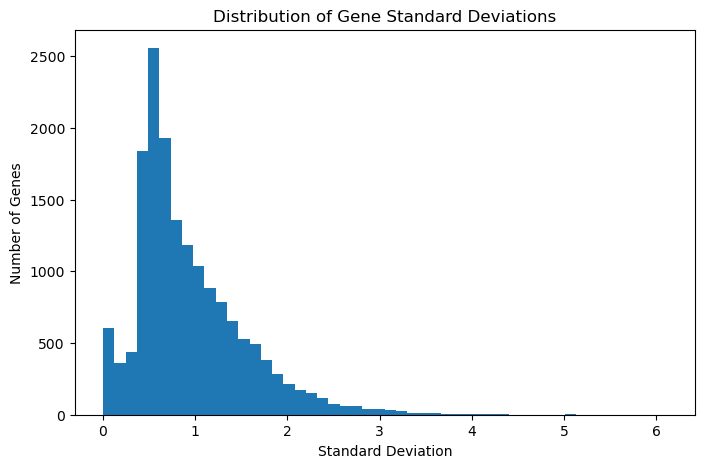

In [18]:
# Histogram of the standard deviations
gene_std = combined_clean.drop(columns="BRCA_subtype").std()

plt.figure(figsize=(8,5))
plt.hist(gene_std, bins=50)
plt.xlabel("Standard Deviation")
plt.ylabel("Number of Genes")
plt.title("Distribution of Gene Standard Deviations")
plt.show()

In [19]:
# find genes with only one unique value (constant features)
constant_features = overview[overview["n_unique"] == 1]

display(constant_features)

,variable,dtype,n_unique
41,RBMY1A3P,float64,1
144,SNORD115-17,int64,1
283,SNORD114-31,int64,1
284,SNORD114-30,int64,1
297,SNORD115-6,int64,1
...,...,...,...
16160,SNORD60,int64,1
16198,TXNDC8,int64,1
16241,TTTY3B,int64,1
16315,KRTAP13-3,int64,1


In [20]:
# names of the constant genes
constant_gene_names = constant_features["variable"].tolist()

print(constant_gene_names)

['RBMY1A3P', 'SNORD115-17', 'SNORD114-31', 'SNORD114-30', 'SNORD115-6', 'SNORD115-4', 'SNORD104', 'SNORD115-9', 'SNORD38A', 'KRTAP19-7', 'KRTAP19-4', 'SNORD114-3', 'HBII-52-27', 'SNORD11', 'SNORD12', 'SNORD21', 'SNORD20', 'SNORD25', 'SNORD127', 'DAZ3', 'DAZ2', 'DAZ4', 'SNORD124', 'TTTY17A', 'SNORD115-5', 'SNORD80', 'SNORD56B', 'SNORD78', 'SNORD113-7', 'SNORD96A', 'SNORD119', 'HBII-52-46', 'HBII-52-45', 'SNORD47', 'SNORD4B', 'SNORD4A', 'SNORD116-24', 'SNORD116-25', 'SNORD116-23', 'SNORD116-29', 'RBMY1B', 'RBMY1F', 'BPY2', 'SNORD115-8', 'SNORD66', 'HBII-52-28', 'SNORD69', 'SNORD68', 'SNORD38B', 'SNORD113-4', 'SNORD116-26', 'SNORD115-1', 'SNORD58A', 'SNORD58C', 'PRR20A', 'PRR20D', 'SNORD96B', 'SNORD63', 'SNORD116-22', 'SNORD81', 'PLA2G2E', 'PRAMEF3', 'SNORD114-20', 'SNAR-A3', 'SNORD115-20', 'SNORD115-22', 'SNORD115-25', 'SNORD114-29', 'TEX28', 'CEACAM18', 'SNORD29', 'S100A7L2', 'LOC653545', 'SNORD16', 'SNORD36A', 'SNORD91B', 'SNORD87', 'SNORD86', 'DEFB116', 'DEFB114', 'DEFB112', 'TTTY4C',

In [21]:
# all constant genes
constant_features = overview[overview["n_unique"] == 1]

display(constant_features)

,variable,dtype,n_unique
41,RBMY1A3P,float64,1
144,SNORD115-17,int64,1
283,SNORD114-31,int64,1
284,SNORD114-30,int64,1
297,SNORD115-6,int64,1
...,...,...,...
16160,SNORD60,int64,1
16198,TXNDC8,int64,1
16241,TTTY3B,int64,1
16315,KRTAP13-3,int64,1


In [22]:
# number of constant genes
print(len(constant_gene_names))
print(f"{len(constant_gene_names)} constant genes found.")

221
221 constant genes found.


In [23]:
# without constant genes
constant_genes = gene_std[gene_std == 0].index #filtering all genes with std=0, index takes only their names
combined_no_constant = combined_clean.drop(columns=constant_genes)

In [24]:
print(combined_clean.shape)
print(combined_no_constant.shape)

(950, 16384)
(950, 16163)


In [25]:
# check if there are still constant genes in the dataset
combined_no_constant.drop(columns="BRCA_subtype").std().min()

np.float64(0.00853284675147811)

In [26]:
# final dataset for analysis
analysis = combined_no_constant.copy()

### Compare sampling methods

In [27]:
target = "BRCA_subtype"
sample_frac = 0.2
n_repeats = 500

# normalize = True: changes absolute counts into relative frequencies/proportions
# Proportion =  number of subtype/total number of patients
# sort_index: sorts alphabetically after label names
original_props = analysis[target].value_counts(normalize=True).sort_index()
original_props

# Output: Proportional shares of each subtype in the entire dataset

BRCA_subtype
Basal     0.146316
Her2      0.070526
LumA      0.455789
LumB      0.202105
Normal    0.125263
Name: proportion, dtype: float64

In [28]:
# test simple random sampling multiple times
# measures how much the subtype distribution in the sample deviates from the original distribution
simple_errors = []

for i in range(n_repeats):
    sample = analysis.sample(frac=sample_frac, random_state=i)
    sample_props = sample[target].value_counts(normalize=True).reindex(original_props.index, fill_value=0)
    #calculate the absolute difference between the sample proportions and the original proportions, then sum them up to get a total error measure
    error = (sample_props - original_props).abs().sum() #How strong does each class deviate, abs. = absolute value
    simple_errors.append(error)

simple_mean_error = np.mean(simple_errors)# average sampling error
simple_mean_error

# Output: On average, a randomly drawn sample deviates by about 9.5 percentage points from the original subtype distribution.

np.float64(0.0950778947368421)

In [29]:
# test stratified sampling multiple times
# measures how much the subtype distribution in the sample deviates from the original distribution
strat_errors = []

for i in range(n_repeats):
    sample = (
        analysis
        .groupby(target, group_keys=False)
        .sample(frac=sample_frac, random_state=i)
    )
    
    sample_props = sample[target].value_counts(normalize=True).reindex(original_props.index, fill_value=0)
    error = (sample_props - original_props).abs().sum()
    strat_errors.append(error)

strat_mean_error = np.mean(strat_errors)
strat_mean_error

# Output: The distribution of a stratified sample deviates on average only by 0.84 percentage points from the overall distribution of the original dataset.

np.float64(0.008421052631578899)

In [30]:
# show comparison of the two sampling methods
comparison = pd.DataFrame({
    "method": ["Simple random sampling", "Stratified sampling"],
    "mean_distribution_error": [simple_mean_error, strat_mean_error]
})

display(comparison)

# Stratified sampling preserves the original subtype distribution better.

,method,mean_distribution_error
0,Simple random sampling,0.095078
1,Stratified sampling,0.008421


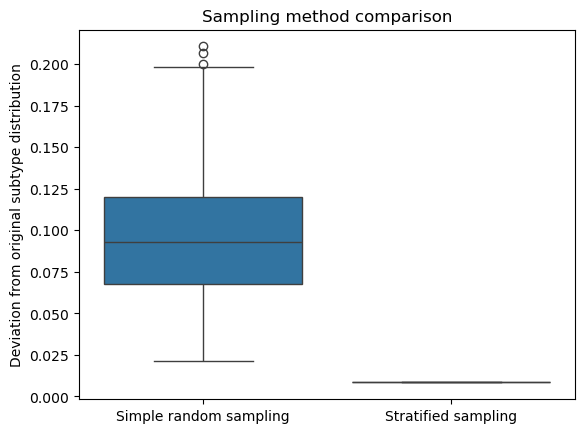

In [31]:
# show visually the comparison of the two sampling methods

error_df = pd.DataFrame({
    "Simple random sampling": simple_errors,
    "Stratified sampling": strat_errors
})

sns.boxplot(data=error_df)
plt.ylabel("Deviation from original subtype distribution")
plt.title("Sampling method comparison")
plt.show()

### Train/Test-Split

In [32]:
# Features and Labels
X = analysis.drop(columns=["BRCA_subtype"])
y = analysis["BRCA_subtype"]

In [33]:
# Stratified Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42, #sorgt für rpoduzierbarkeit
    stratify=y #sampling art
)
# 20 % test data
# 80% training data

In [34]:
# check shapes
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (760, 16162)
X_test: (190, 16162)
y_train: (760,)
y_test: (190,)


In [35]:
# check if the distributions are similar
print(y.value_counts(normalize=True))

print(y_train.value_counts(normalize=True))

print(y_test.value_counts(normalize=True))

BRCA_subtype
LumA      0.455789
LumB      0.202105
Basal     0.146316
Normal    0.125263
Her2      0.070526
Name: proportion, dtype: float64
BRCA_subtype
LumA      0.455263
LumB      0.202632
Basal     0.146053
Normal    0.125000
Her2      0.071053
Name: proportion, dtype: float64
BRCA_subtype
LumA      0.457895
LumB      0.200000
Basal     0.147368
Normal    0.126316
Her2      0.068421
Name: proportion, dtype: float64


## Hyperparameter Tuning

In [36]:
# define the pipeline
pipe = Pipeline([
    ("variance", VarianceThreshold()),
    ("scaler", StandardScaler()),
    ("select", SelectKBest(score_func=f_classif)), #f_classif/mutual_info_classif
    ("model", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=42
    ))
])

# define the parameter grid for GridSearchCV --> where select__k is the number of features to select and model__C is the regularization strength for Logistic Regression
param_grid = {
    "select__k": [200, 300, 350, 400, 450, 500, 750, 1000],
    "model__C": [0.01, 0.1, 1, 10]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring="f1_macro", 
    # not balanced accuracy, because we want to optimize the performance across all classes
    # balanced accuracy would overrate the performance of the smaller classes, as they are on average worse
    # F1_macro considers the performance across all classes and is thus better
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_k = grid.best_params_["select__k"]
best_C = grid.best_params_["model__C"]

print("Best k:", grid.best_params_["select__k"])
print("Best C:", grid.best_params_["model__C"])
print("Best CV score:", grid.best_score_)

Best k: 400
Best C: 1
Best CV score: 0.9188957266200612


## Feature Selection

During the splitting, new genes can become constant --> add another VarianceThreshold

In [37]:
pipe_anova_logreg = Pipeline([
    ("variance", VarianceThreshold()), #removes train-constant genes
    ("select", SelectKBest(score_func=f_classif, k=best_k)), #selects top k genes
    ("model", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=42
    ))
])

pipe_anova_logreg.fit(X_train, y_train)
pred_anova_logreg = pipe_anova_logreg.predict(X_test)
print(classification_report(y_test, pred_anova_logreg))

              precision    recall  f1-score   support

       Basal       1.00      0.93      0.96        28
        Her2       0.85      0.85      0.85        13
        LumA       0.91      0.91      0.91        87
        LumB       0.82      0.87      0.85        38
      Normal       0.92      0.92      0.92        24

    accuracy                           0.90       190
   macro avg       0.90      0.89      0.90       190
weighted avg       0.90      0.90      0.90       190



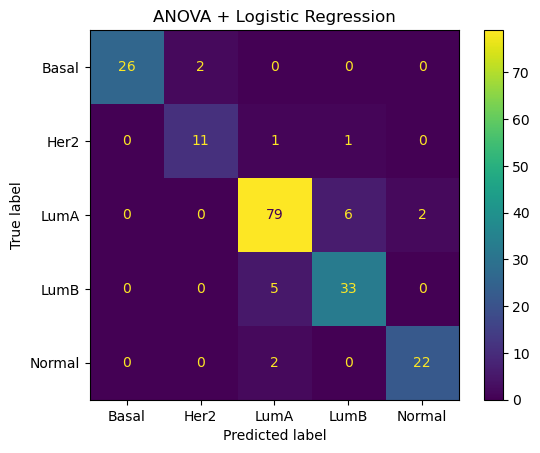

In [38]:
#Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, pred_anova_logreg)
plt.title("ANOVA + Logistic Regression")
plt.show()

### Selected Genes

In [39]:
# get mask of selected features
selected_mask = pipe_anova_logreg.named_steps["select"].get_support()

# apply mask to original column names
selected_genes = X_train.columns[
    pipe_anova_logreg.named_steps["variance"].get_support()
][selected_mask]

selected_genes

Index(['HIF3A', 'LRRTM2', 'CAMKV', 'GTSE1', 'THSD4', 'CHST3', 'GPSM2',
       'ZNF703', 'CKS1B', 'ART3',
       ...
       'TUBB', 'POLQ', 'KIAA1370', 'CX3CL1', 'KCNK15', 'OVCH2', 'NCAPD2',
       'SLC6A14', 'FXYD1', 'KDM4B'],
      dtype='str', length=400)

In [40]:
# Baseline Logistic Regression (without Feature Selection)
baseline_model = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    random_state=42
)

baseline_model.fit(X_train, y_train)
baseline_pred = baseline_model.predict(X_test)
print(classification_report(y_test, baseline_pred))

              precision    recall  f1-score   support

       Basal       1.00      0.93      0.96        28
        Her2       0.67      0.77      0.71        13
        LumA       0.88      0.90      0.89        87
        LumB       0.78      0.76      0.77        38
      Normal       0.91      0.88      0.89        24

    accuracy                           0.86       190
   macro avg       0.85      0.85      0.85       190
weighted avg       0.87      0.86      0.86       190



In [42]:
# Comparison Table
baseline_accuracy = accuracy_score(y_test, baseline_pred)
baseline_macro_f1 = f1_score(y_test, baseline_pred, average="macro")
baseline_her2_recall = recall_score(
    y_test,
    baseline_pred,
    labels=["Her2"],
    average=None
)[0]

print("Baseline Accuracy:", baseline_accuracy)
print("Baseline Macro F1:", baseline_macro_f1)
print("Baseline Her2 Recall:", baseline_her2_recall)

Baseline Accuracy: 0.8631578947368421
Baseline Macro F1: 0.8461125336444486
Baseline Her2 Recall: 0.7692307692307693


In [43]:
anova_accuracy = accuracy_score(y_test, pred_anova_logreg)
anova_macro_f1 = f1_score(y_test, pred_anova_logreg, average="macro")
anova_her2_recall = recall_score(
    y_test,
    pred_anova_logreg,
    labels=["Her2"],
    average=None
)[0]

print("ANOVA Accuracy:", anova_accuracy)
print("ANOVA Macro F1:", anova_macro_f1)
print("ANOVA Her2 Recall:", anova_her2_recall)

ANOVA Accuracy: 0.9
ANOVA Macro F1: 0.8959966597897633
ANOVA Her2 Recall: 0.8461538461538461


In [44]:
#compare baseline and ANOVA feature selection
comparison = pd.DataFrame({
    "Model": [
        "Baseline Logistic Regression",
        "ANOVA + Logistic Regression"
    ],
    "Accuracy": [
        baseline_accuracy,
        anova_accuracy
    ],
    "Macro F1": [
        baseline_macro_f1,
        anova_macro_f1
    ],
    "Her2 Recall": [
        baseline_her2_recall,
        anova_her2_recall
    ],
    "Number of Features": [
        X_train.shape[1],
        500
    ]
})

comparison

,Model,Accuracy,Macro F1,Her2 Recall,Number of Features
0,Baseline Logistic Regression,0.863158,0.846113,0.769231,16162
1,ANOVA + Logistic Regression,0.900000,0.895997,0.846154,500


## Model Selection

tested models:

LogRegCV

LogRegEN

RF

SVM 

### Define & train models
With Pipeline: "Pipeline allows you to sequentially apply a list of transformers to preprocess the data and, if desired, conclude the sequence with a final predictor for predictive modeling."

In [45]:
PREPROCESSING = [
    ("variance", VarianceThreshold()),
    ("select",   SelectKBest(score_func=f_classif, k=best_k)),
    ("scaler",   StandardScaler()),
]

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)



#### 1) Logistic Regression mit L2-Regularisierung

In [46]:
# 1) Logistic Regression L2
pipe_lr = Pipeline(PREPROCESSING + [
    ("model", LogisticRegressionCV(
        Cs=np.logspace(-3, 1, 8),
        cv=5,
        penalty="l2",
        solver="lbfgs",
        scoring="balanced_accuracy",
        class_weight="balanced",
        max_iter=2000,
        random_state=42,
        n_jobs=-1
    ))
])

print("Training LogReg L2 ...")
pipe_lr.fit(X_train, y_train)
print(f"  Best C: {pipe_lr.named_steps['model'].C_[0]:.4f}")
print("  Done.\n")

Training LogReg L2 ...


c:\Users\41787\anaconda3\envs\fods\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
c:\Users\41787\anaconda3\envs\fods\Lib\site-packages\sklearn\linear_model\_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
c:\Users\41787\anaconda3\envs\fods\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=Fal

  Best C: 0.0139
  Done.



#### 2) Logistic Regression mit Elastic Net

In [47]:
# 2) Logistic Regression Elastic Net
pipe_en = Pipeline(PREPROCESSING + [
    ("model", LogisticRegressionCV(
        Cs=np.logspace(-3, 1, 8),
        cv=5,
        penalty="elasticnet",
        solver="saga",
        l1_ratios=[0.1, 0.5, 0.9],
        scoring="balanced_accuracy",
        class_weight="balanced",
        max_iter=3000,
        random_state=42,
        n_jobs=-1
    ))
])

print("Training Elastic Net ...")
pipe_en.fit(X_train, y_train)
print(f"  Best C:        {pipe_en.named_steps['model'].C_[0]:.4f}")
print(f"  Best l1_ratio: {pipe_en.named_steps['model'].l1_ratio_[0]:.2f}")
print("  Done.\n")

Training Elastic Net ...


c:\Users\41787\anaconda3\envs\fods\Lib\site-packages\sklearn\linear_model\_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
c:\Users\41787\anaconda3\envs\fods\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(


  Best C:        0.1931
  Best l1_ratio: 0.10
  Done.



#### 3) Random Forest

In [48]:
# 3) Random Forest
pipe_rf = Pipeline(PREPROCESSING + [
    ("model", RandomForestClassifier(
        n_estimators=best_k,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

print("Training Random Forest ...")
pipe_rf.fit(X_train, y_train)
print("  Finished.\n")

Training Random Forest ...
  Finished.



#### 4) Support Vector Machine

In [49]:
# 4) SVM (GridSearchCV über C)
base_svm = SVC(
    kernel="linear",
    class_weight="balanced",
    probability=True,
    random_state=42
)

pipe_svm = Pipeline(PREPROCESSING + [
    ("model", GridSearchCV(
        estimator=base_svm,
        param_grid={"C": [0.001, 0.01, 0.1, 1, 10]},
        cv=cv_strategy,
        scoring="balanced_accuracy",
        n_jobs=-1,
        verbose=1
    ))
])

print("Training SVM (GridSearchCV über C) ...")
pipe_svm.fit(X_train, y_train)
print(f"  Best C:        {pipe_svm.named_steps['model'].best_params_['C']}")
print(f"  Best CV-Score: {pipe_svm.named_steps['model'].best_score_:.4f}")
print("  Done.\n")

Training SVM (GridSearchCV über C) ...
Fitting 5 folds for each of 5 candidates, totalling 25 fits
  Best C:        0.01
  Best CV-Score: 0.9284
  Done.



### Evaluation on the test set

In [50]:
# Evaluate all models
# Balanced Accuracy: average of recall values per class --> takes imbalance into account
# We collect predictions and metrics for all 4 models in a dictionary

# Evaluation auf dem Testset
pipelines = {
    "LogReg L2":     pipe_lr,
    "Elastic Net":   pipe_en,
    "Random Forest": pipe_rf,
    "SVM (linear)":  pipe_svm,
}

results = {}

for name, pipe in pipelines.items():
    print(f"\n{'─'*55}")
    print(f" {name}")
    print(f"{'─'*55}")
    y_pred = pipe.predict(X_test)
    ba = balanced_accuracy_score(y_test, y_pred)
    results[name] = {"pipe": pipe, "y_pred": y_pred, "balanced_acc": ba}
    print(f"Balanced Accuracy: {ba:.4f}\n")
    print(classification_report(y_test, y_pred))



───────────────────────────────────────────────────────
 LogReg L2
───────────────────────────────────────────────────────
Balanced Accuracy: 0.9004

              precision    recall  f1-score   support

       Basal       1.00      0.93      0.96        28
        Her2       0.80      0.92      0.86        13
        LumA       0.94      0.84      0.88        87
        LumB       0.76      0.89      0.82        38
      Normal       0.85      0.92      0.88        24

    accuracy                           0.88       190
   macro avg       0.87      0.90      0.88       190
weighted avg       0.89      0.88      0.88       190


───────────────────────────────────────────────────────
 Elastic Net
───────────────────────────────────────────────────────
Balanced Accuracy: 0.9036

              precision    recall  f1-score   support

       Basal       0.96      0.93      0.95        28
        Her2       0.86      0.92      0.89        13
        LumA       0.93      0.90      0.91 

### Overview & Best Model

In [ ]:
# Coparison table
comparison = (
    pd.DataFrame({
        "Model":            list(results.keys()),
        "Balanced Accuracy": [v["balanced_acc"] for v in results.values()],
        "Her2 Recall": [sk_recall_score(y_test, v["y_pred"], labels=["Her2"], average=None)[0] for v in results.values()],
        "F1 Macro": [sk_f1_score(y_test, v["y_pred"], average="macro") for v in results.values()]
    })
    .sort_values("Balanced Accuracy", ascending=False)
    .reset_index(drop=True)
)

comparison.index += 1
comparison.index.name = "Place"
print("\n" + "-"*61)
print(" MODEL COMPARISON – Balanced Accuracy")
print("-"*61)
print(comparison.to_string())

best_model = comparison.iloc[0]["Model"]
best_res  = results[best_model]["pipe"].named_steps["model"]
best_acc  = results[best_model]["balanced_acc"]
best_f1_macro = sk_f1_score(y_test, results[best_model]["y_pred"], average="macro")
best_recall = sk_recall_score(y_test, results[best_model]["y_pred"], average=None, labels=best_res.classes_)

print(f"\n→ Best Model: {best_model} ({best_acc:.4f}) | Her2 Recall: {best_recall[best_res.classes_ == 'Her2'][0]:.4f} | F1-Score: {best_f1_macro:.4f}")



-------------------------------------------------------------
 MODEL COMPARISON – Balanced Accuracy
-------------------------------------------------------------
               Model  Balanced Accuracy  Her2 Recall  F1 Macro
Place                                                         
1        Elastic Net           0.903587     0.923077  0.898048
2          LogReg L2           0.900426     0.923077  0.880846
3       SVM (linear)           0.884376     0.846154  0.876496
4      Random Forest           0.793282     0.461538  0.817652

→ Best Model: Elastic Net (0.9036) | Her2 Recall: 0.9231 | F1-Score: 0.8980


In [ ]:
# Compare all 4 models on Evaluation Metrics
# Use the same class order as the first fitted model
first_model = list(results.values())[0]["pipe"]
classes = first_model.classes_

y_test_bin = label_binarize(y_test, classes=classes)

rows = []

for model_name, res in results.items():
    pipe = res["pipe"]
    y_pred = res["y_pred"]

    # Scores for ROC-AUC and PR-AUC
    # Prefer predict_proba; if unavailable, use decision_function
    if hasattr(pipe, "predict_proba"):
        y_score = pipe.predict_proba(X_test)
    else:
        y_score = pipe.decision_function(X_test)

    # Metrics
    balanced_acc = balanced_accuracy_score(y_test, y_pred)

    macro_precision = precision_score(
        y_test, y_pred,
        average="macro",
        zero_division=0
    )

    macro_recall = recall_score(
        y_test, y_pred,
        average="macro",
        zero_division=0
    )

    macro_f1 = f1_score(
        y_test, y_pred,
        average="macro",
        zero_division=0
    )

    weighted_f1 = f1_score(
        y_test, y_pred,
        average="weighted",
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        y_score,
        labels=classes,
        multi_class="ovr",
        average="macro"
    )

    pr_auc = average_precision_score(
        y_test_bin,
        y_score,
        average="macro"
    )

    rows.append({
        "Model": model_name,
        "Balanced Accuracy": balanced_acc,
        "Precision Macro Avg": macro_precision,
        "Recall Macro Avg": macro_recall,
        "F1 Macro Avg": macro_f1,
        "Weighted F1": weighted_f1,
        "ROC-AUC OvR": roc_auc,
        "PR-AUC OvR": pr_auc
    })


comparison_full = pd.DataFrame(rows)

# Round nicely
comparison_full_rounded = comparison_full.copy()
numeric_cols = comparison_full_rounded.columns.drop("Model")
comparison_full_rounded[numeric_cols] = comparison_full_rounded[numeric_cols].round(3)

comparison_full_rounded


,Model,Balanced Accuracy,Precision Macro Avg,Recall Macro Avg,F1 Macro Avg,Weighted F1,ROC-AUC OvR,PR-AUC OvR
0,LogReg L2,0.900,0.868,0.900,0.881,0.881,0.983,0.925
1,Elastic Net,0.904,0.894,0.904,0.898,0.901,0.984,0.941
2,Random Forest,0.793,0.854,0.793,0.818,0.865,0.978,0.906
3,SVM (linear),0.884,0.872,0.884,0.876,0.881,0.983,0.931


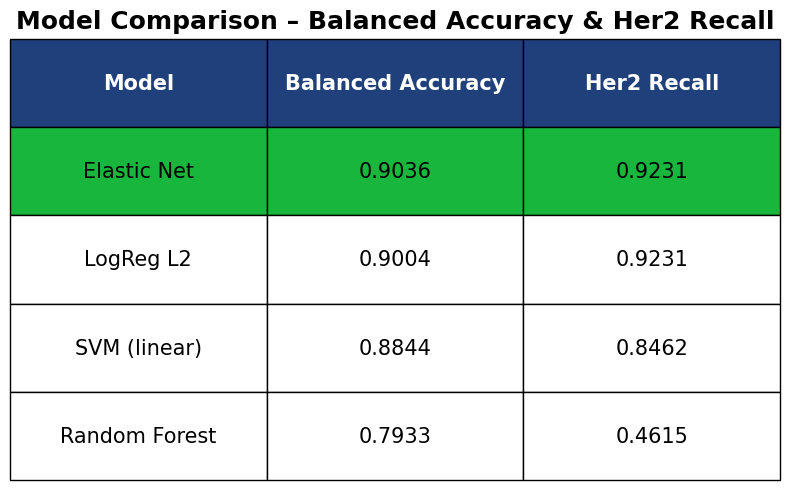

In [54]:
# Visual comparison table

fig, ax = plt.subplots(figsize=(8, 5))
ax.axis("off")

data = comparison[["Model", "Balanced Accuracy", "Her2 Recall"]].copy()
data["Balanced Accuracy"] = data["Balanced Accuracy"].map("{:.4f}".format)
data["Her2 Recall"] = data["Her2 Recall"].map("{:.4f}".format)

table = ax.table(
    cellText=data.values,
    colLabels=data.columns,
    cellLoc="center",
    loc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(15)
table.scale(1, 5)

# Color Header
for j in range(len(data.columns)):
    table[0, j].set_facecolor("#1F407A")
    table[0, j].set_text_props(color="white", fontweight="bold")

# Highlight the best result
for j in range(len(data.columns)):
    table[1, j].set_facecolor("#18b63d")

plt.title("Model Comparison – Balanced Accuracy & Her2 Recall", fontsize=18, fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig("modellvergleich.png", dpi=150, bbox_inches="tight")
plt.show()

#### Confusion Matrices of all models

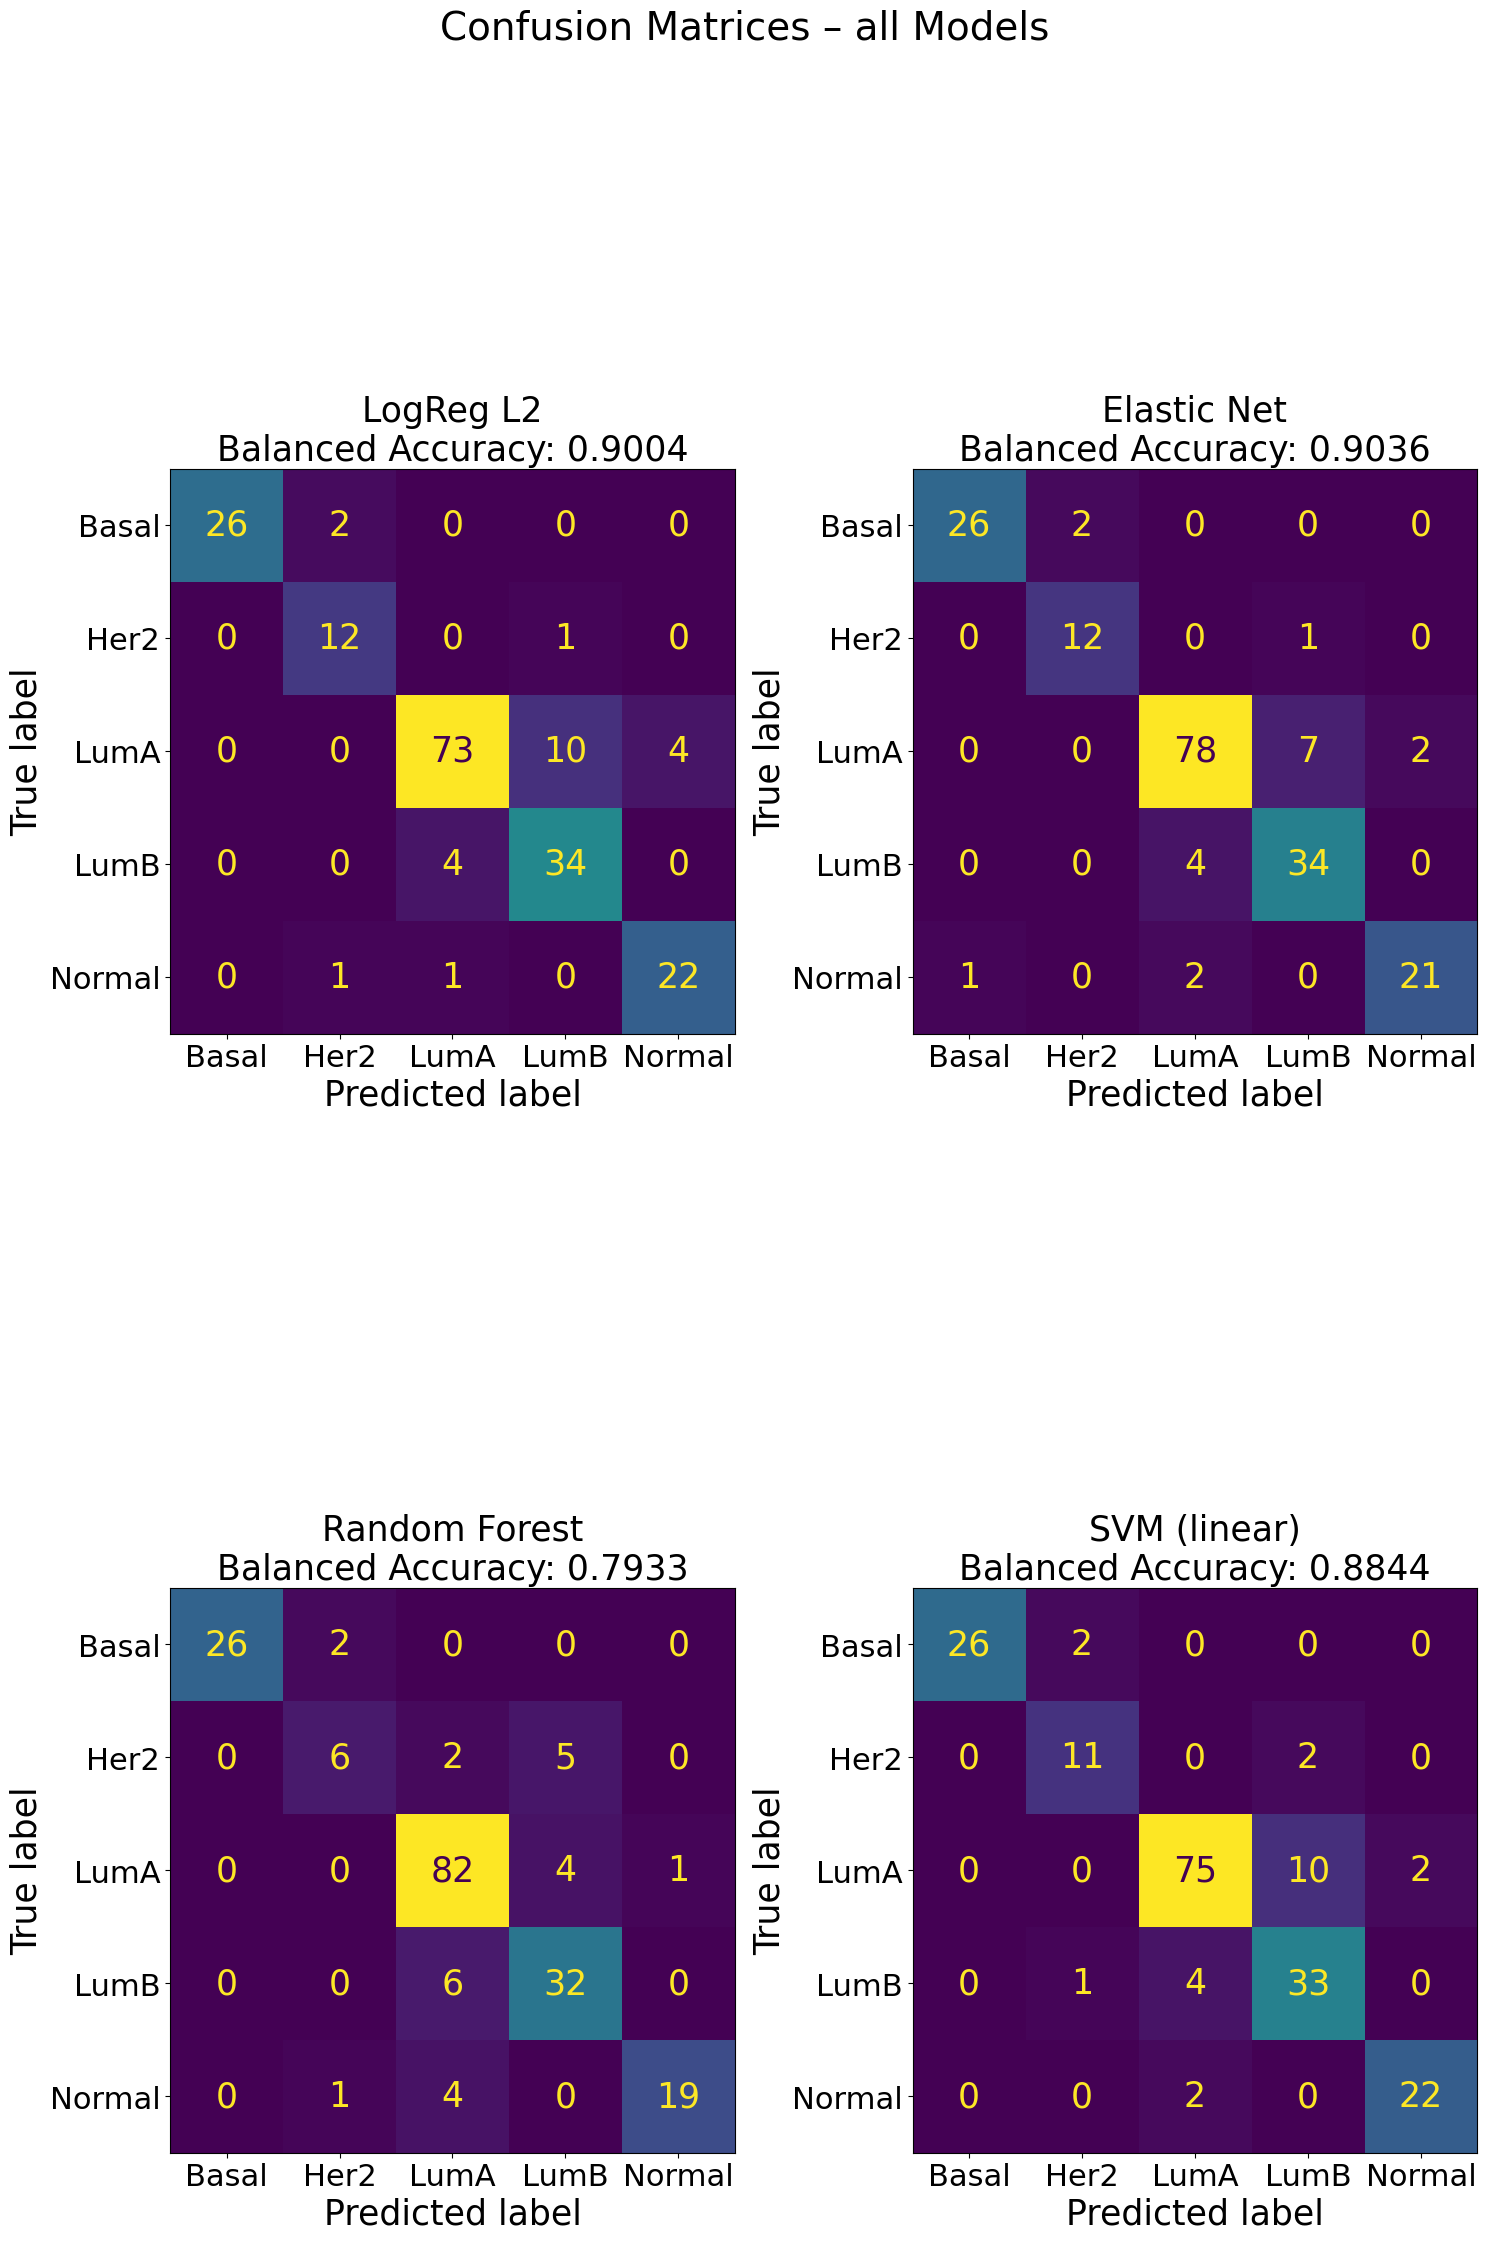

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 25))
classes = best_res.classes_

for ax, (name, res) in zip(axes.flatten(), results.items()):
    cm = confusion_matrix(y_test, res["y_pred"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(ax=ax, colorbar=False, cmap=colormaps["viridis"])
    
    # Numbers in the cells larger
    for text in disp.text_.ravel():
        text.set_fontsize(25)
    
    ax.set_title(f"{name}\nBalanced Accuracy: {res['balanced_acc']:.4f}", fontsize=25)
    ax.set_xlabel("Predicted label", fontsize=25)
    ax.set_ylabel("True label", fontsize=25)
    ax.tick_params(labelsize=22)  # Axis labels (Basal, Her2, ...)

plt.suptitle("Confusion Matrices – all Models", fontsize=28, y=1.01)
plt.tight_layout()


plt.show()

### Feature Importance --> most important genes

In [56]:
#Depending on the model, interpretation differs:
#- LogReg / Elastic Net: Coefficients show, which genes are important for which subtype
#- Random Forest: Feature Importance shows global importance for all subtypes
#- SVM: Coefficient Vector for linear kernel shows which genes are important for separating the classes, but interpretation is less straightforward than in Logistic Regression

# Feature Importance of the best model
best_name  = comparison.iloc[0]["Model"]          # e.g. "Elastic Net"
best_pipe  = results[best_name]["pipe"]             # whole pipeline
best_clf   = best_pipe.named_steps["model"]         # only the classifier (e.g. LogisticRegressionCV, RandomForestClassifier, GridSearchCV with SVC)    

# reconstruct gene names after VarianceThreshold + SelectKBest
var_mask    = best_pipe.named_steps["variance"].get_support()
select_mask = best_pipe.named_steps["select"].get_support()
selected_genes = X_train.columns[var_mask][select_mask]

print(f"Feature-Analysis for: {best_name}\n")

if best_name in ("LogReg L2", "Elastic Net"):
    coef_df = pd.DataFrame(
        best_clf.coef_,
        index=best_clf.classes_,
        columns=selected_genes
    )
    print("Top 5 genes per subtype (absolute coefficients):")
    for subtype in best_clf.classes_:
        top5 = coef_df.loc[subtype].abs().sort_values(ascending=False).head(5)
        print(f"  {subtype}: {list(top5.index)}")

elif best_name == "Random Forest":
    importances = pd.Series(
        best_clf.feature_importances_,
        index=selected_genes
    ).sort_values(ascending=False)
    print("Top 10 Genes (Random Forest Feature Importance):")
    print(importances.head(10).to_string())

elif best_name == "SVM (linear)":
    # best_clf is here a GridSearchCV object → .best_estimator_ fetches the SVC
    svc = best_clf.best_estimator_
    coef_df = pd.DataFrame(svc.coef_, columns=selected_genes)
    print("Top 5 Genes with largest absolute SVM weights (all classes):")
    top_genes = coef_df.abs().max(axis=0).sort_values(ascending=False).head(5)
    print(top_genes.to_string())


Feature-Analysis for: Elastic Net

Top 5 genes per subtype (absolute coefficients):
  Basal: ['ZNF454', 'FOXC1', 'GDF5', 'GFRA3', 'ATL2']
  Her2: ['ESR1', 'FLJ45983', 'TRIM3', 'CCDC125', 'C6orf97']
  LumA: ['BCL2', 'RANBP1', 'NAT1', 'PIF1', 'FOXC1']
  LumB: ['PPP1R14C', 'SCUBE2', 'GFAP', 'C6orf97', 'PDGFD']
  Normal: ['OXTR', 'GLRA4', 'KCNMB1', 'CNN1', 'NAT1']


## Train best model

Make sure to create a new model --> other models have already seen test data

Where are hyperparameters from (C, l1_ratio)?
--> pipe_en has searched the best values internally via 5-Fold Cross Validation on X_train. These CV-Ergebnisse are clean (no test set involved), which is why we take C and l1_ratio straight from there

In [57]:
# Read best hyperparameter from the CV Comparison
# pipe_en.named_steps["model"] is the LogisticRegressionCV object
best_C        = results["Elastic Net"]["pipe"].named_steps["model"].C_[0]
best_l1_ratio = results["Elastic Net"]["pipe"].named_steps["model"].l1_ratio_[0]

print(f"Imported Hyperparameters from CV:")
print(f"  C        = {best_C:.4f}")
print(f"  l1_ratio = {best_l1_ratio:.2f}")
print()


Imported Hyperparameters from CV:
  C        = 0.1931
  l1_ratio = 0.10



In [58]:
# Define final pipeline with best hyperparameters
# Identical preprocessing as in the comparison (VarianceThreshold → SelectKBest → Scaler)
# now LogisticRegression (not CV variant), because the hyperparameters are already fixed and do not need to be searched anymore.

final_pipe = Pipeline([
    ("variance", VarianceThreshold()),                          # removes train-constant genes
    ("select",   SelectKBest(score_func=f_classif, k=best_k)),  # top k genes via ANOVA
    ("scaler",   StandardScaler()),                             # z-standardization
    ("model",    LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        C=best_C,                  # best C from CV
        l1_ratio=best_l1_ratio,    # best l1_ratio from CV
        class_weight="balanced",   # compensates class imbalance (Her2 rare)
        max_iter=3000,
        random_state=42
    ))
])

In [59]:
# training on train set
# X_train / y_train: the 80 % that the model is allowed to see.
# X_test  / y_test:  will be used in the next step – only once.
print("Training final model on X_train ...")
final_pipe.fit(X_train, y_train)
print("  Done.\n")

final_pred_train = final_pipe.predict(X_train)

Training final model on X_train ...


c:\Users\41787\anaconda3\envs\fods\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


  Done.



In [60]:
# Evaluation on test set
# This is the only and last touch with the test data.
# The resulting Balanced Accuracy is the official final model performance.
final_pred_test = final_pipe.predict(X_test)
final_ba   = balanced_accuracy_score(y_test, final_pred_test)
final_accuracy = accuracy_score(y_test, final_pred_test)

print("\n" + "-"*42)
print(" FINAL MODEL - Evaluation on the test set")
print("-"*42)
print(f"Balanced Accuracy: {final_ba:.4f}")
print(f"Accuracy: {final_accuracy:.4f}\n")
print(classification_report(y_test, final_pred_test))


------------------------------------------
 FINAL MODEL - Evaluation on the test set
------------------------------------------
Balanced Accuracy: 0.8953
Accuracy: 0.8947

              precision    recall  f1-score   support

       Basal       0.96      0.93      0.95        28
        Her2       0.80      0.92      0.86        13
        LumA       0.93      0.90      0.91        87
        LumB       0.81      0.89      0.85        38
      Normal       0.91      0.83      0.87        24

    accuracy                           0.89       190
   macro avg       0.88      0.90      0.89       190
weighted avg       0.90      0.89      0.90       190



### Hierarchical Classifier

is trained on same data as the model --> practically useless

In [61]:
# hierarchical classifier
# Idea: in insecure LumA/LumB-predictions a specialized binary classifier (LumA vs. LumB) could be more accurate than the main multi-class classifier, 
# which has to separate all 4 classes at once.

# Spezialized LumA vs. LumB classifier
lum_mask = y_train.isin(["LumA", "LumB"])
X_lum    = X_train[lum_mask]
y_lum    = y_train[lum_mask]
threshold = 0.7 #defines how confident the main classifier has to be in its LumA/LumB prediction, so that we do not use the specialized classifier for uncertain cases

lum_pipe = Pipeline([
    ("variance", VarianceThreshold()),
    ("select",   SelectKBest(f_classif, k=best_k)),
    ("scaler",   StandardScaler()),
    ("model",    LogisticRegression(
        C=0.1,
        class_weight="balanced",
        max_iter=5000,
        random_state=42,
        penalty="l2",
    ))
])

lum_pipe.fit(X_lum, y_lum)

# hierarchical prediction function
def predict_hierarchical(X, main_pipe, lum_pipe, threshold=threshold):
    main_proba   = main_pipe.predict_proba(X)
    main_classes = main_pipe.classes_
    hier_pred    = main_pipe.predict(X).tolist()

    lum_a_idx = list(main_classes).index("LumA")
    lum_b_idx = list(main_classes).index("LumB")

    for i, pred in enumerate(hier_pred):
        if pred in ["LumA", "LumB"]:
            p_luma = main_proba[i][lum_a_idx]
            p_lumb = main_proba[i][lum_b_idx]
            lum_confidence = max(p_luma, p_lumb) / (p_luma + p_lumb)

            if lum_confidence < threshold:
                hier_pred[i] = lum_pipe.predict(X.iloc[[i]])[0]

    return hier_pred

hier_pred  = predict_hierarchical(X_test, final_pipe, lum_pipe, threshold=threshold)
hier_ba    = balanced_accuracy_score(y_test, hier_pred)

# Comparison of the hierarchical classifier with the original final model
print("\n" + "-"*54)
print(" HIERARCHICAL CLASSIFIER vs. FINAL MODEL (Balanced Accuracy)")
print("-"*54)
print(f"  Final Model (Elastic Net): {final_ba:.4f}")
print(f"  Final Model + Hierarchical Classifier:    {hier_ba:.4f}")
print(f"  Difference:                   {hier_ba - final_ba:+.4f}")
print()
print(classification_report(y_test, hier_pred))

c:\Users\41787\anaconda3\envs\fods\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(



------------------------------------------------------
 HIERARCHICAL CLASSIFIER vs. FINAL MODEL (Balanced Accuracy)
------------------------------------------------------
  Final Model (Elastic Net): 0.8953
  Final Model + Hierarchical Classifier:    0.8976
  Difference:                   +0.0023

              precision    recall  f1-score   support

       Basal       0.96      0.93      0.95        28
        Her2       0.80      0.92      0.86        13
        LumA       0.93      0.91      0.92        87
        LumB       0.83      0.89      0.86        38
      Normal       0.91      0.83      0.87        24

    accuracy                           0.90       190
   macro avg       0.89      0.90      0.89       190
weighted avg       0.90      0.90      0.90       190



### Visualization L2 vs Elastic Net

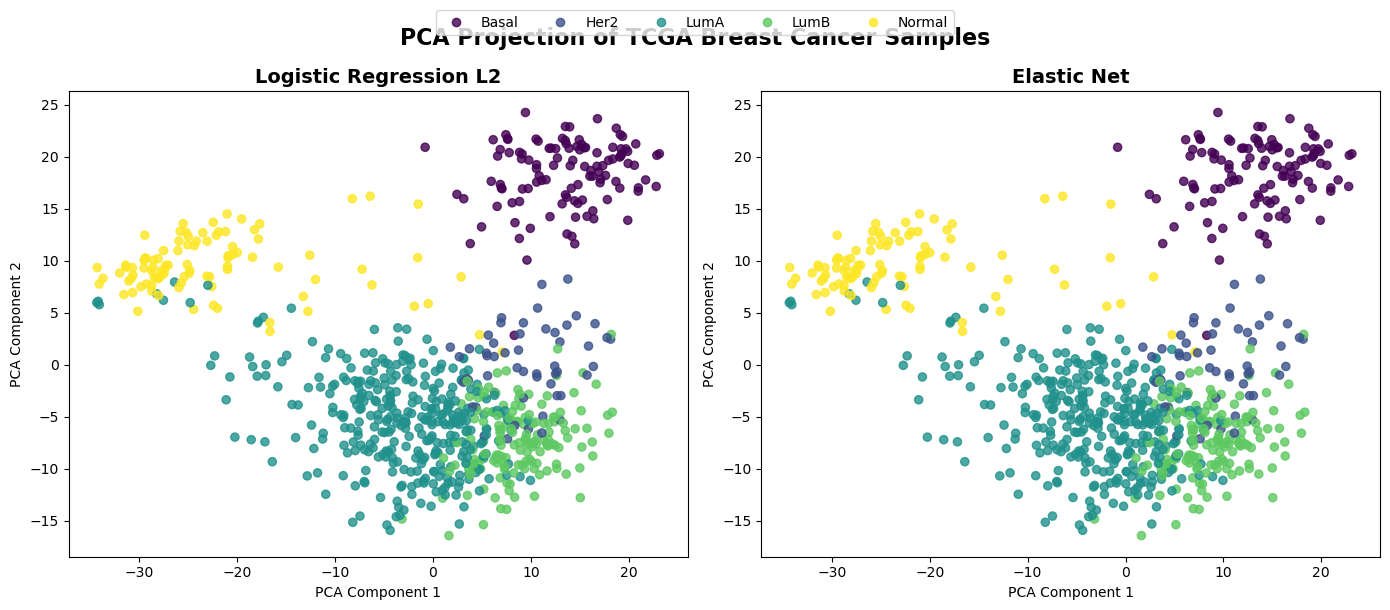

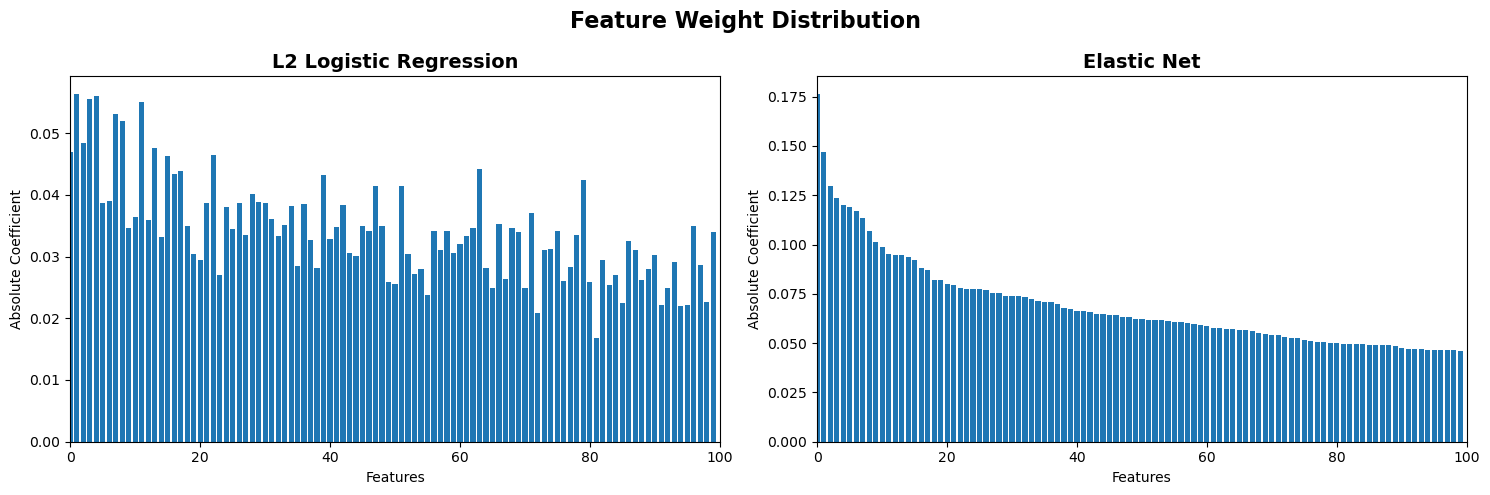


---------------------------------------
Non-Zero Coefficients
---------------------------------------
L2 Logistic Regression : 400
Elastic Net            : 373

Interpretation:
- L2 uses almost all features with small coefficients
- Elastic Net removes many irrelevant genes
- This leads to less overfitting and better generalization


In [87]:
l2_pipe = results["LogReg L2"]["pipe"]
en_pipe = results["Elastic Net"]["pipe"]

# preprocessing steps in the pipeline: VarianceThreshold --> SelectKBest --> StandardScaler
def transform_features(pipe, X):
    X_var = pipe.named_steps["variance"].transform(X)
    X_sel = pipe.named_steps["select"].transform(X_var)
    X_scl = pipe.named_steps["scaler"].transform(X_sel)
    return X_scl

X_l2 = transform_features(l2_pipe, X_train)
X_en = transform_features(en_pipe, X_train)

# code labels to integers for coloring in PCA plot
classes = np.unique(y_train)
class_to_int = {c: i for i, c in enumerate(classes)}
y_num = np.array([class_to_int[c] for c in y_train])

# PCA in 2D for visualization of the feature space
pca = PCA(n_components=2, random_state=42)

X_l2_pca = pca.fit_transform(X_l2)
X_en_pca = pca.fit_transform(X_en)

#Figure 1: PCA Projection of the feature space after preprocessing for both models
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

scatter1 = axes[0].scatter(
    X_l2_pca[:, 0],
    X_l2_pca[:, 1],
    c=y_num,
    s=35,
    alpha=0.8
)

axes[0].set_title("Logistic Regression L2", fontsize=14, weight="bold")
axes[0].set_xlabel("PCA Component 1")
axes[0].set_ylabel("PCA Component 2")

scatter2 = axes[1].scatter(
    X_en_pca[:, 0],
    X_en_pca[:, 1],
    c=y_num,
    s=35,
    alpha=0.8
)

axes[1].set_title("Elastic Net", fontsize=14, weight="bold")
axes[1].set_xlabel("PCA Component 1")
axes[1].set_ylabel("PCA Component 2")

# combined legend for both subplots
handles = scatter2.legend_elements()[0]
fig.legend(
    handles,
    classes,
    loc="upper center",
    ncol=len(classes),
    bbox_to_anchor=(0.5, 1.02)
)

fig.suptitle(
    "PCA Projection of TCGA Breast Cancer Samples",
    fontsize=16,
    weight="bold"
)

plt.tight_layout()
plt.show()

# FIgure 2: Barplot of the absolute coefficients for both models, sorted by importance in Elastic Net
# mean of the absolute coefficients across all classes (for multi-class models) to get a single importance value per gene
l2_coef = np.mean(np.abs(l2_pipe.named_steps["model"].coef_), axis=0)
en_coef = np.mean(np.abs(en_pipe.named_steps["model"].coef_), axis=0)

n_features = len(l2_coef)

# sorting the coefficients by importance in Elastic Net
sort_idx = np.argsort(en_coef)[::-1]

l2_sorted = l2_coef[sort_idx]
en_sorted = en_coef[sort_idx]

# show only the top 100 features for better visualization
top_n = min(100, n_features)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# L2
axes[0].bar(
    np.arange(top_n),
    l2_sorted[:top_n]
)

axes[0].set_title("L2 Logistic Regression", fontsize=14, weight="bold")
axes[0].set_xlabel("Features")
axes[0].set_ylabel("Absolute Coefficient")
axes[0].set_xlim(0, top_n)

# Elastic Net
axes[1].bar(
    np.arange(top_n),
    en_sorted[:top_n]
)

axes[1].set_title("Elastic Net", fontsize=14, weight="bold")
axes[1].set_xlabel("Features")
axes[1].set_ylabel("Absolute Coefficient")
axes[1].set_xlim(0, top_n)

plt.suptitle(
    "Feature Weight Distribution",
    fontsize=16,
    weight="bold"
)

plt.tight_layout()
plt.show()

# additional analysis: count how many non-zero coefficients each model has (with a small threshold to account for numerical precision)
l2_nonzero = np.sum(l2_coef > 1e-6)
en_nonzero = np.sum(en_coef > 1e-6)

print("\n" + "-"*39)
print("Non-Zero Coefficients")
print("-"*39)
print(f"L2 Logistic Regression : {l2_nonzero}")
print(f"Elastic Net            : {en_nonzero}")

print("\nInterpretation:")
print("- L2 uses almost all features with small coefficients")
print("- Elastic Net removes many irrelevant genes")
print("- This leads to less overfitting and better generalization")

## Model Analysis & Interpretation

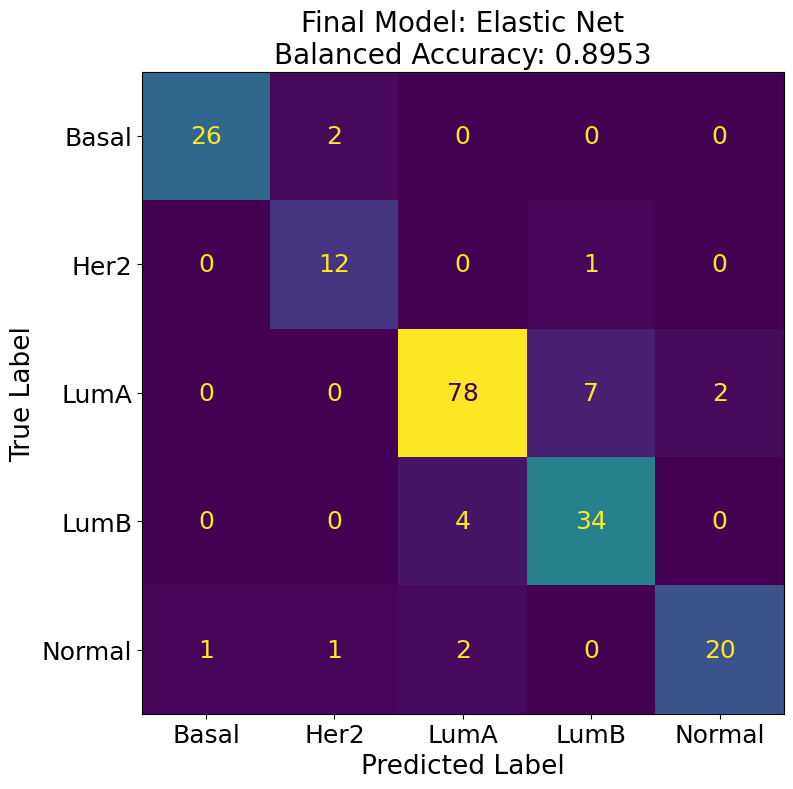

In [88]:
# Confusion Matrix for the final model (Elastic Net)
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    final_pred_test,
    ax=ax,
    colorbar=False
)
ax.set_title(
    f"Final Model: Elastic Net\nBalanced Accuracy: {final_ba:.4f}",
    fontsize=20
)

ax.set_xlabel("Predicted Label", fontsize=19)
ax.set_ylabel("True Label", fontsize=19)
for text in ax.texts:
    text.set_fontsize(18)
ax.tick_params(axis="both", labelsize=18)

plt.tight_layout()
plt.show()

In [66]:
# Comparison of Train and Test Performance

def compute_metrics(y_true, y_pred, dataset_name):
    return {
        "Dataset": dataset_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Macro Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Weighted F1": f1_score(y_true, y_pred, average="weighted", zero_division=0)
    }

train_metrics = compute_metrics(y_train, final_pred_train, "Train")
test_metrics = compute_metrics(y_test, final_pred_test, "Test")

train_test_comparison = pd.DataFrame([train_metrics, test_metrics])

# Add generalization gap
gap = train_test_comparison.iloc[0, 1:] - train_test_comparison.iloc[1, 1:]
gap_row = pd.DataFrame([["Gap: Train - Test"] + list(gap)], columns=train_test_comparison.columns)

train_test_comparison = pd.concat(
    [train_test_comparison, gap_row],
    ignore_index=True
)

train_test_comparison

,Dataset,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Train,0.996053,0.998266,0.996178,0.998266,0.997200,0.996063
1,Test,0.894737,0.895254,0.882030,0.895254,0.886889,0.895545
2,Gap: Train - Test,0.101316,0.103012,0.114149,0.103012,0.110311,0.100518


In [67]:
# Per-Class Recall Comparison

train_report = classification_report(
    y_train,
    final_pred_train,
    output_dict=True,
    zero_division=0
)

test_report = classification_report(
    y_test,
    final_pred_test,
    output_dict=True,
    zero_division=0
)

per_class_recall = pd.DataFrame({
    "Class": classes,
    "Train Recall": [train_report[cls]["recall"] for cls in classes],
    "Test Recall": [test_report[cls]["recall"] for cls in classes],
})

per_class_recall["Recall Gap"] = (
    per_class_recall["Train Recall"] - per_class_recall["Test Recall"]
)

per_class_recall

,Class,Train Recall,Test Recall,Recall Gap
0,Basal,1.000000,0.928571,0.071429
1,Her2,1.000000,0.923077,0.076923
2,LumA,0.991329,0.896552,0.094778
3,LumB,1.000000,0.894737,0.105263
4,Normal,1.000000,0.833333,0.166667


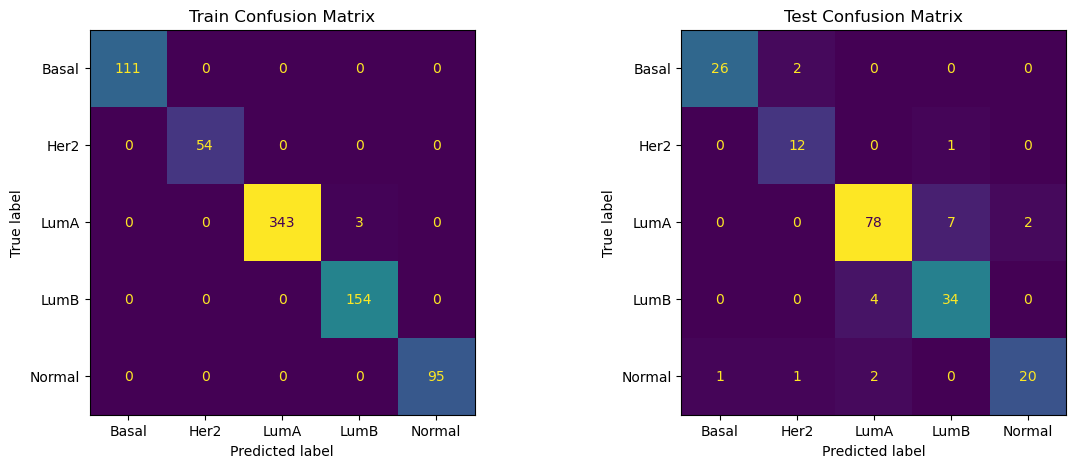

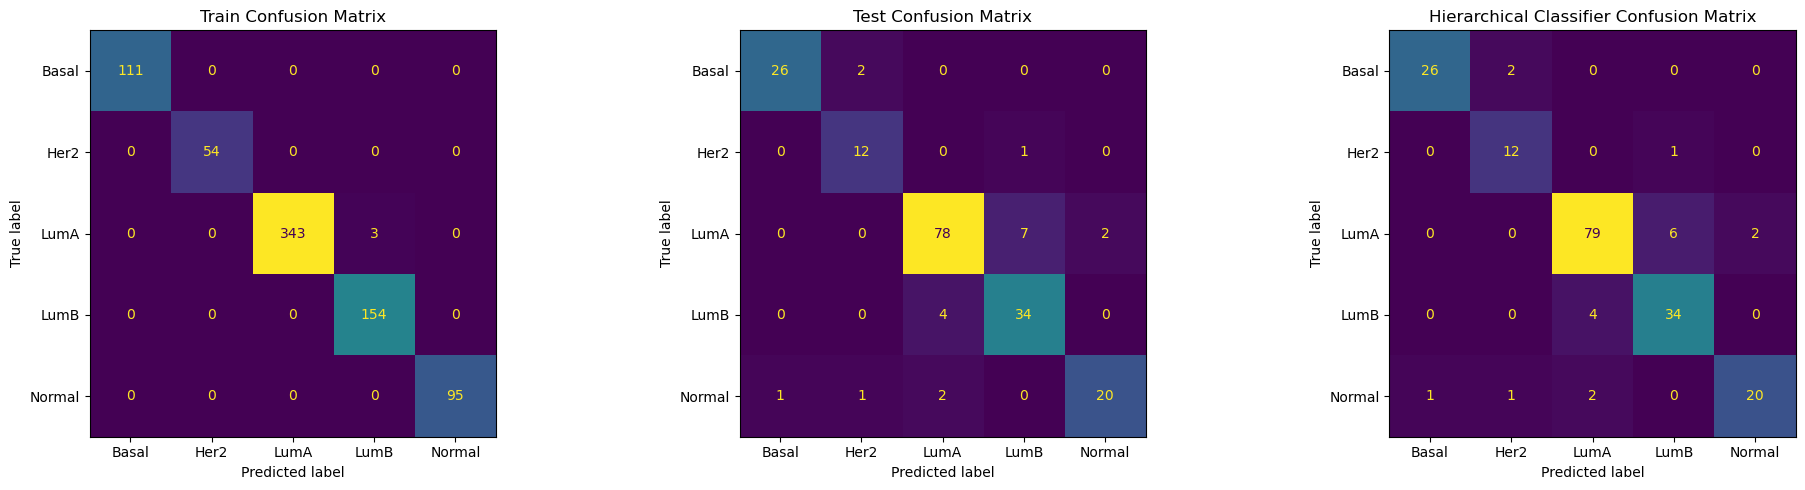

<Figure size 640x480 with 0 Axes>

In [68]:
# Confusion Matrix Comparison

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_train = confusion_matrix(y_train, final_pred_train, labels=classes)
cm_test = confusion_matrix(y_test, final_pred_test, labels=classes)
cm_classifier= confusion_matrix(y_test, hier_pred, labels=classes)

ConfusionMatrixDisplay(cm_train, display_labels=classes).plot(
    ax=axes[0],
    colorbar=False
)
axes[0].set_title("Train Confusion Matrix")

ConfusionMatrixDisplay(cm_test, display_labels=classes).plot(
    ax=axes[1],
    colorbar=False
)
axes[1].set_title("Test Confusion Matrix")

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

cm_train = confusion_matrix(y_train, final_pred_train, labels=classes)
cm_test = confusion_matrix(y_test, final_pred_test, labels=classes)
cm_classifier = confusion_matrix(y_test, hier_pred, labels=classes)

ConfusionMatrixDisplay(cm_train, display_labels=classes).plot(
    ax=axes[0],
    colorbar=False
)
axes[0].set_title("Train Confusion Matrix")

ConfusionMatrixDisplay(cm_test, display_labels=classes).plot(
    ax=axes[1],
    colorbar=False
)
axes[1].set_title("Test Confusion Matrix")

ConfusionMatrixDisplay(cm_classifier, display_labels=classes).plot(
    ax=axes[2],
    colorbar=False
)
axes[2].set_title("Hierarchical Classifier Confusion Matrix")

plt.tight_layout()
plt.show()
axes[2].set_title("hierarchical Classifier Confusion Matrix")

plt.tight_layout()
plt.show()

In [69]:
# Bootstrap Confidence Intervals for Metrics

def bootstrap_metric_ci(
    y_true,
    y_pred,
    y_proba,
    classes,
    n_bootstraps=1000,
    random_state=42
):
    rng = np.random.default_rng(random_state)
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_proba = np.array(y_proba)

    records = []

    for b in range(n_bootstraps):
        idx = rng.choice(
            np.arange(len(y_true)),
            size=len(y_true),
            replace=True
        )

        y_true_b = y_true[idx]
        y_pred_b = y_pred[idx]
        y_proba_b = y_proba[idx]

        # Skip bootstrap samples missing classes for ROC-AUC
        y_true_bin_b = label_binarize(y_true_b, classes=classes)

        metric_values = {
            "Accuracy": accuracy_score(y_true_b, y_pred_b),
            "Balanced Accuracy": balanced_accuracy_score(y_true_b, y_pred_b),
            "Macro Precision": precision_score(y_true_b, y_pred_b, average="macro", zero_division=0),
            "Macro Recall": recall_score(y_true_b, y_pred_b, average="macro", zero_division=0),
            "Macro F1": f1_score(y_true_b, y_pred_b, average="macro", zero_division=0),
            "Weighted F1": f1_score(y_true_b, y_pred_b, average="weighted", zero_division=0),
        }

        try:
            metric_values["Macro ROC-AUC OvR"] = roc_auc_score(
                y_true_bin_b,
                y_proba_b,
                average="macro",
                multi_class="ovr"
            )
        except ValueError:
            metric_values["Macro ROC-AUC OvR"] = np.nan

        # Her2-specific recall if Her2 exists
        if "Her2" in classes:
            her2_true = (y_true_b == "Her2")
            her2_pred = (y_pred_b == "Her2")

            if her2_true.sum() > 0:
                metric_values["Her2 Recall"] = recall_score(
                    her2_true,
                    her2_pred,
                    zero_division=0
                )
            else:
                metric_values["Her2 Recall"] = np.nan

        records.append(metric_values)

    boot_df = pd.DataFrame(records)

    summary = []

    for metric in boot_df.columns:
        values = boot_df[metric].dropna()

        summary.append({
            "Metric": metric,
            "Mean": values.mean(),
            "Std": values.std(),
            "CI 2.5%": np.percentile(values, 2.5),
            "CI 97.5%": np.percentile(values, 97.5),
            "N valid bootstraps": len(values)
        })

    return pd.DataFrame(summary)


y_test_proba = results["Elastic Net"]["pipe"].predict_proba(X_test)

bootstrap_ci_table = bootstrap_metric_ci(
    y_true=y_test,
    y_pred=final_pred_test,
    y_proba=y_test_proba,
    classes=classes,
    n_bootstraps=1000,
    random_state=42
)

bootstrap_ci_table

bootstrap_ci_table

,Metric,Mean,Std,CI 2.5%,CI 97.5%,N valid bootstraps
0,Accuracy,0.894532,0.022204,0.852632,0.936842,1000
1,Balanced Accuracy,0.895086,0.025664,0.844054,0.943326,1000
2,Macro Precision,0.882181,0.028764,0.823377,0.938503,1000
3,Macro Recall,0.895086,0.025664,0.844054,0.943326,1000
4,Macro F1,0.884880,0.026753,0.832033,0.934652,1000
5,Weighted F1,0.895514,0.021857,0.852605,0.937428,1000
6,Macro ROC-AUC OvR,0.983805,0.005030,0.972873,0.992750,1000
7,Her2 Recall,0.921476,0.074575,0.750000,1.000000,1000


### Learning Curves

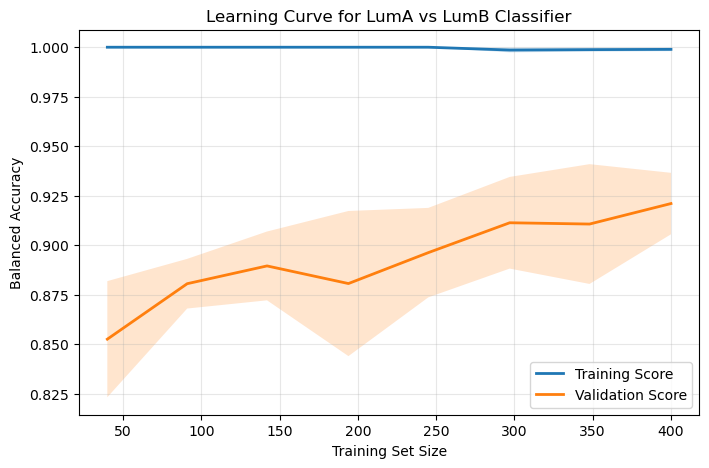

In [ ]:
# Learning Curve: Overfitting / Underfitting Diagnose
# shows Train- and CV-Score in dependency of the training set size
# define training set sizes (10% to 100% of the training data)
train_sizes = np.linspace(0.1, 1.0, 8)

# calculate learning curve for the specialized LumA vs. LumB classifier
sizes, train_scores, val_scores = learning_curve(
    estimator=lum_pipe,
    X=X_lum,
    y=y_lum,
    cv=5,
    scoring="balanced_accuracy",
    train_sizes=train_sizes,
    n_jobs=-1
)

# mean and std across the 5 CV folds for each training set size
train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)

val_mean = val_scores.mean(axis=1)
val_std  = val_scores.std(axis=1)

# Plot
plt.figure(figsize=(8, 5))

plt.plot(sizes, train_mean, linewidth=2, label="Training Score")
plt.plot(sizes, val_mean, linewidth=2, label="Validation Score")

plt.fill_between(
    sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.2
)

plt.fill_between(
    sizes,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.2
)

plt.xlabel("Training Set Size")
plt.ylabel("Balanced Accuracy")
plt.title("Learning Curve for LumA vs LumB Classifier")

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

### Most Important Genes

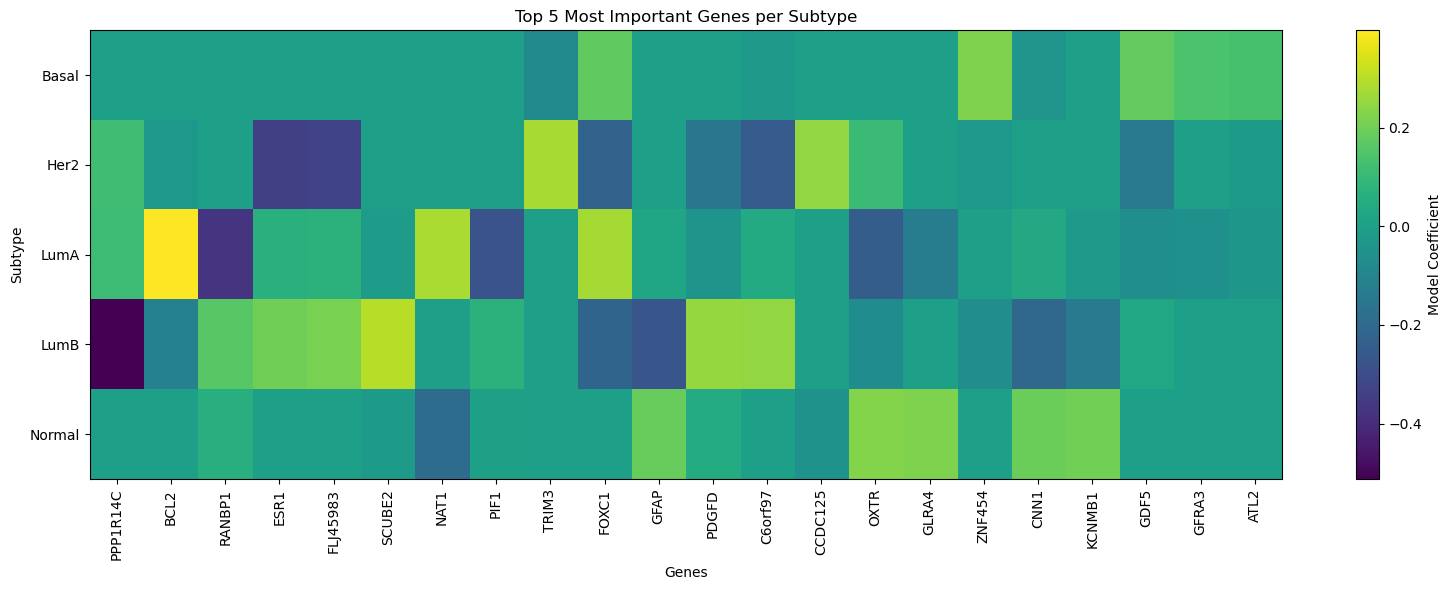

In [ ]:
# Coefficient-heatmap: most important genes per subtype
# uses the final model coefficients for biological interpretability
# number of top genes to show per subtype
TOP_N = 5

# Get the final model
model = final_pipe.named_steps["model"]

# if feature selection is part of the pipeline, get the selected feature names, otherwise use all original features
if "feature_selection" in final_pipe.named_steps:
    selector = final_pipe.named_steps["feature_selection"]
    selected_features = X.columns[selector.get_support()]
else:
    selected_features = X.columns

# extract coefficients
# get the selected feature names from the pipeline
var_mask = final_pipe.named_steps["variance"].get_support()
select_mask = final_pipe.named_steps["select"].get_support()
selected_features = X_train.columns[var_mask][select_mask]

coef_df = pd.DataFrame(
    final_pipe.named_steps["model"].coef_,
    columns=selected_features,
    index=final_pipe.named_steps["model"].classes_
)

# top-N genes per subtype based on absolute coefficients
top_genes = set()

for subtype in coef_df.index:
    top = coef_df.loc[subtype].abs().sort_values(ascending=False).head(TOP_N)
    top_genes.update(top.index)

top_genes = list(top_genes)

# only relevant coefficients for the top genes
plot_df = coef_df[top_genes]

# sort genes by their maximum absolute coefficient across all subtypes for better visualization
gene_order = (
    plot_df.abs()
    .max(axis=0)
    .sort_values(ascending=False)
    .index
)

plot_df = plot_df[gene_order]

# Heatmap
fig, ax = plt.subplots(figsize=(16, 6))

im = ax.imshow(
    plot_df,
    aspect="auto"
)

# Axis labels
ax.set_xticks(np.arange(len(plot_df.columns)))
ax.set_xticklabels(plot_df.columns, rotation=90)

ax.set_yticks(np.arange(len(plot_df.index)))
ax.set_yticklabels(plot_df.index)

# Title + Labels
ax.set_title(f"Top {TOP_N} Most Important Genes per Subtype")
ax.set_xlabel("Genes")
ax.set_ylabel("Subtype")

# Colorbar
cbar = plt.colorbar(im)
cbar.set_label("Model Coefficient")

plt.tight_layout()
plt.show()

### Evaluation Metrics

In [ ]:
# LogReg L2, Random Forest, SVM from results
# Final Elastic Net from final_pipe
# Elastic Net + Hierarchical from final_pipe + lum_pipe
# get class order from pipeline/model

def get_classes(pipe):
    if hasattr(pipe, "classes_"):
        return np.array(pipe.classes_)
    
    if hasattr(pipe, "named_steps"):
        if "model" in pipe.named_steps:
            model = pipe.named_steps["model"]
        else:
            model = list(pipe.named_steps.values())[-1]
        
        if hasattr(model, "classes_"):
            return np.array(model.classes_)
        
        if hasattr(model, "best_estimator_"):
            return np.array(model.best_estimator_.classes_)
    
    raise ValueError("Could not find model classes.")


# align probability columns to same class order

def align_scores_to_classes(y_score, score_classes, target_classes):
    y_score = np.asarray(y_score)
    aligned = np.zeros((y_score.shape[0], len(target_classes)))
    
    for j, cls in enumerate(score_classes):
        target_idx = list(target_classes).index(cls)
        aligned[:, target_idx] = y_score[:, j]
    
    return aligned

# safe single-row selection

def get_single_row(X, i):
    if hasattr(X, "iloc"):
        return X.iloc[[i]]
    return X[[i]]


# Her2 recall


def her2_recall_score(y_true, y_pred):
    return recall_score(
        y_true,
        y_pred,
        labels=["Her2"],
        average=None,
        zero_division=0
    )[0]


# calculate one row of metrics


def calculate_metrics_row(model_name, pipe, X_test, y_test, classes, y_test_bin):
    y_pred = pipe.predict(X_test)
    
    model_classes = get_classes(pipe)
    y_score_raw = pipe.predict_proba(X_test)
    y_score = align_scores_to_classes(y_score_raw, model_classes, classes)
    
    return {
        "Model": model_name,
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "Her2 Recall": her2_recall_score(y_test, y_pred),
        "F1 Macro Avg": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "ROC-AUC OvR": roc_auc_score(
            y_test,
            y_score,
            labels=classes,
            multi_class="ovr",
            average="macro"
        ),
        "PR-AUC OvR": average_precision_score(
            y_test_bin,
            y_score,
            average="macro"
        )
    }


# Hierarchical classifier with probabilities


def predict_hierarchical_with_proba(X, main_pipe, lum_pipe, threshold=0.7, classes=None):
    if classes is None:
        classes = get_classes(main_pipe)

    main_classes = get_classes(main_pipe)
    main_proba_raw = main_pipe.predict_proba(X)
    main_proba = align_scores_to_classes(main_proba_raw, main_classes, classes)

    hier_pred = main_pipe.predict(X).tolist()

    lum_classes = get_classes(lum_pipe)
    lum_proba_raw = lum_pipe.predict_proba(X)
    lum_proba = align_scores_to_classes(
        lum_proba_raw,
        lum_classes,
        np.array(["LumA", "LumB"])
    )

    lum_a_idx = list(classes).index("LumA")
    lum_b_idx = list(classes).index("LumB")

    for i, pred in enumerate(hier_pred):
        if pred in ["LumA", "LumB"]:
            p_luma = main_proba[i, lum_a_idx]
            p_lumb = main_proba[i, lum_b_idx]
            lum_total = p_luma + p_lumb

            if lum_total > 0:
                lum_confidence = max(p_luma, p_lumb) / lum_total

                if lum_confidence < threshold:
                    X_one = get_single_row(X, i)

                    hier_pred[i] = lum_pipe.predict(X_one)[0]

                    main_proba[i, lum_a_idx] = lum_total * lum_proba[i, 0]
                    main_proba[i, lum_b_idx] = lum_total * lum_proba[i, 1]

    return np.array(hier_pred), main_proba


# Global class order from the FINAL Elastic Net model

classes = get_classes(final_pipe)
y_test_bin = label_binarize(y_test, classes=classes)


# Build corrected comparison table

rows = []

# Use the non-final comparison models from results
rows.append(
    calculate_metrics_row(
        "LogReg L2",
        results["LogReg L2"]["pipe"],
        X_test,
        y_test,
        classes,
        y_test_bin
    )
)

# Use FINAL Elastic Net
rows.append(
    calculate_metrics_row(
        "Elastic Net",
        final_pipe,
        X_test,
        y_test,
        classes,
        y_test_bin
    )
)

rows.append(
    calculate_metrics_row(
        "Random Forest",
        results["Random Forest"]["pipe"],
        X_test,
        y_test,
        classes,
        y_test_bin
    )
)

rows.append(
    calculate_metrics_row(
        "SVM (linear)",
        results["SVM (linear)"]["pipe"],
        X_test,
        y_test,
        classes,
        y_test_bin
    )
)



# Elastic Net + Hierarchical
hier_threshold = threshold if "threshold" in globals() else 0.7

hier_pred, hier_proba = predict_hierarchical_with_proba(
    X_test,
    main_pipe=final_pipe,
    lum_pipe=lum_pipe,
    threshold=hier_threshold,
    classes=classes
)

rows.append({
    "Model": "Elastic Net + Hierarchical",
    "Balanced Accuracy": balanced_accuracy_score(y_test, hier_pred),
    "Precision": precision_score(y_test, hier_pred, average="macro", zero_division=0),
    "Her2 Recall": her2_recall_score(y_test, hier_pred),
    "F1 Macro Avg": f1_score(y_test, hier_pred, average="macro", zero_division=0),
    "ROC-AUC OvR": roc_auc_score(
        y_test,
        hier_proba,
        labels=classes,
        multi_class="ovr",
        average="macro"
    ),
    "PR-AUC OvR": average_precision_score(
        y_test_bin,
        hier_proba,
        average="macro"
    )
})



# Table
comparison_full = pd.DataFrame(rows)

comparison_full_rounded = comparison_full.copy()
numeric_cols = comparison_full_rounded.columns.drop("Model")
comparison_full_rounded[numeric_cols] = comparison_full_rounded[numeric_cols].round(3)

comparison_full_rounded

,Model,Balanced Accuracy,Precision,Her2 Recall,F1 Macro Avg,ROC-AUC OvR,PR-AUC OvR
0,LogReg L2,0.900,0.868,0.923,0.881,0.983,0.925
1,Elastic Net,0.895,0.882,0.923,0.887,0.984,0.939
2,Random Forest,0.793,0.854,0.462,0.818,0.978,0.906
3,SVM (linear),0.884,0.872,0.846,0.876,0.983,0.931
4,Elastic Net + Hierarchical,0.898,0.886,0.923,0.890,0.984,0.941


Macro ROC-AUC OvR:    0.9837
Weighted ROC-AUC OvR: 0.9778


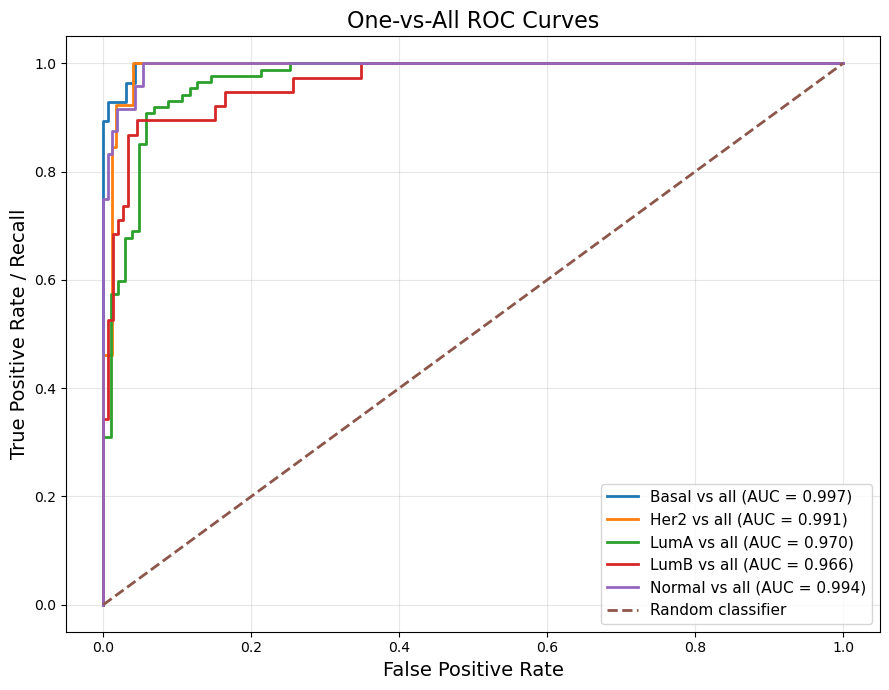

In [ ]:
# One-vs-All ROC-AUC Curve for Multiclass Classification
# Use your final trained model
model_to_plot = final_pipe   # or use: results["Elastic Net"]["pipe"]

# Predicted probabilities
y_score = model_to_plot.predict_proba(X_test)

# Class order from the model
classes = model_to_plot.named_steps["model"].classes_

# Binarize y_test: each subtype becomes one-vs-all
y_test_bin = label_binarize(y_test, classes=classes)

# Calculate macro and weighted ROC-AUC
macro_auc = roc_auc_score(
    y_test,
    y_score,
    multi_class="ovr",
    average="macro"
)

weighted_auc = roc_auc_score(
    y_test,
    y_score,
    multi_class="ovr",
    average="weighted"
)

print(f"Macro ROC-AUC OvR:    {macro_auc:.4f}")
print(f"Weighted ROC-AUC OvR: {weighted_auc:.4f}")

# Plot ROC curves
plt.figure(figsize=(9, 7))

for i, subtype in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{subtype} vs all (AUC = {roc_auc:.3f})"
    )

# Random classifier line
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=2, label="Random classifier")

plt.xlabel("False Positive Rate", fontsize=14)
plt.ylabel("True Positive Rate / Recall", fontsize=14)
plt.title("One-vs-All ROC Curves", fontsize=16)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

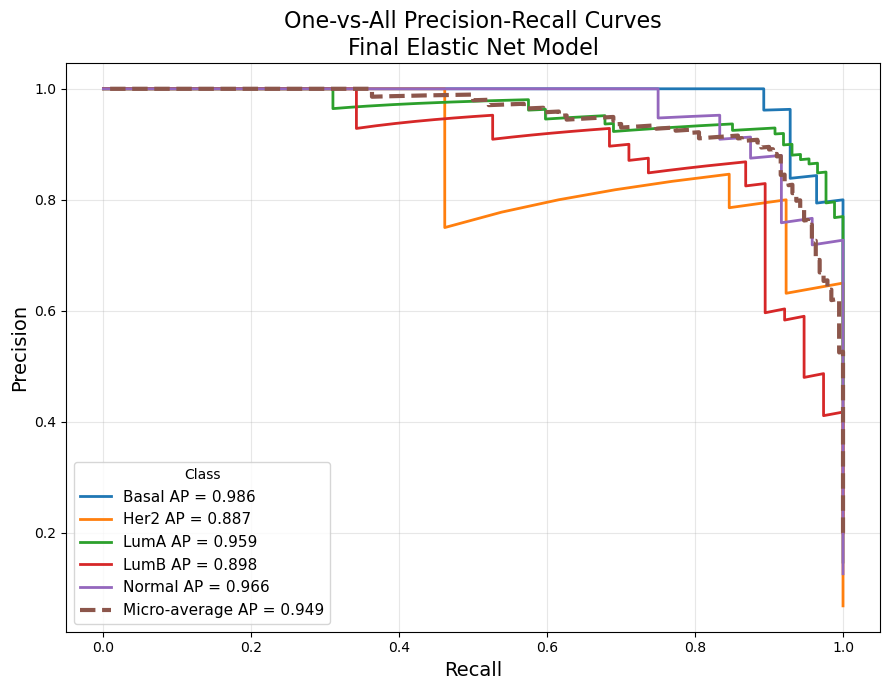

In [ ]:

# One-vs-All Precision-Recall Curves
# 1) Get class order from the final trained Elastic Net model

classes = final_pipe.classes_


# 2) Predict class probabilities on the test set

y_score = final_pipe.predict_proba(X_test)

# 3) Binarize y_test for One-vs-All evaluation
#    Each class is treated once as "positive",
#    all other classes are treated as "negative".

y_test_bin = label_binarize(y_test, classes=classes)

# 4) Compute PR curve and Average Precision for each class

precision = {}
recall = {}
avg_precision = {}

for i, cls in enumerate(classes):
    precision[cls], recall[cls], _ = precision_recall_curve(
        y_test_bin[:, i],
        y_score[:, i]
    )
    
    avg_precision[cls] = average_precision_score(
        y_test_bin[:, i],
        y_score[:, i]
    )

# 5) Micro-average PR curve
#    Pools all class decisions together.

precision_micro, recall_micro, _ = precision_recall_curve(
    y_test_bin.ravel(),
    y_score.ravel()
)

avg_precision_micro = average_precision_score(
    y_test_bin,
    y_score,
    average="micro"
)

# 6) Plot
plt.figure(figsize=(9, 7))

for cls in classes:
    plt.plot(
        recall[cls],
        precision[cls],
        linewidth=2,
        label=f"{cls} AP = {avg_precision[cls]:.3f}"
    )

plt.plot(
    recall_micro,
    precision_micro,
    linestyle="--",
    linewidth=3,
    label=f"Micro-average AP = {avg_precision_micro:.3f}"
)

plt.xlabel("Recall", fontsize=14)
plt.ylabel("Precision", fontsize=14)
plt.title("One-vs-All Precision-Recall Curves\nFinal Elastic Net Model", fontsize=16)

plt.legend(title="Class", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Visualization for hierarchical classifier

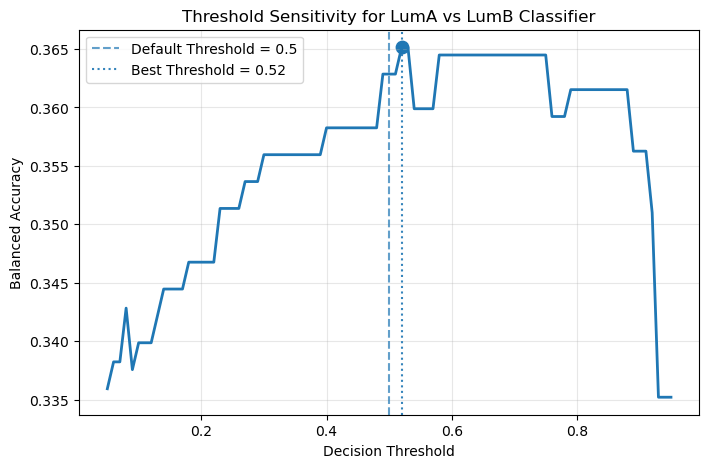

Best Threshold: 0.520
Best Balanced Accuracy: 0.365


In [ ]:
# Threshold-Sensitivity-Curve for the hierarchical classifier
# shows how the balanced accuracy changes when we adjust the confidence threshold for using the specialized LumA vs. LumB classifier
# Probabilities for LumB (positive class)
probs = lum_pipe.predict_proba(X_test)[:, list(lum_pipe.classes_).index("LumB")]

# test thresholds
thresholds = np.linspace(0.05, 0.95, 91)

ba_scores = []

for t in thresholds:
    preds = ["LumB" if p >= t else "LumA" for p in probs]  
    ba = balanced_accuracy_score(y_test, preds)            
    ba_scores.append(ba)

# define best threshold based on the highest balanced accuracy
best_idx = np.argmax(ba_scores)
best_threshold = thresholds[best_idx]
best_ba = ba_scores[best_idx]

#  Plot
plt.figure(figsize=(8, 5))

plt.plot(thresholds, ba_scores, linewidth=2)

plt.axvline(
    0.5,
    linestyle="--",
    alpha=0.7,
    label="Default Threshold = 0.5"
)

plt.axvline(
    best_threshold,
    linestyle=":",
    alpha=0.9,
    label=f"Best Threshold = {best_threshold:.2f}"
)

plt.scatter(best_threshold, best_ba, s=80)

plt.xlabel("Decision Threshold")
plt.ylabel("Balanced Accuracy")
plt.title("Threshold Sensitivity for LumA vs LumB Classifier")

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

print(f"Best Threshold: {best_threshold:.3f}")
print(f"Best Balanced Accuracy: {best_ba:.3f}")

In [ ]:
# Learning Curve Function: diagnosising/Underfitting
cvstrategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
def plot_learning_curve(
    estimator,
    X,
    y,
    cv,
    scorer="balanced_accuracy",
    train_sizes=np.linspace(0.1, 1.0, 5),
    title=None,
    ax=None,
    n_jobs=-1
):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))

    sizes, train_scores, val_scores = learning_curve(
        estimator=estimator,
        X=X,
        y=y,
        cv=cvstrategy,
        scoring=scorer,
        train_sizes=train_sizes,
        n_jobs=n_jobs,
    )

    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    ax.plot(sizes, train_mean, marker="o", linewidth=2, label="Training Score")
    ax.plot(sizes, val_mean,  marker="o", linewidth=2, label="Validation Score")

    ax.fill_between(
        sizes,
        train_mean - train_std,
        train_mean + train_std,
        alpha=0.2
    )
    ax.fill_between(
        sizes,
        val_mean - val_std,
        val_mean + val_std,
        alpha=0.2
    )

    ax.set_xlabel("Training Set Size")
    ax.set_ylabel(scorer.replace("_", " ").title())
    if title is not None:
        ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()

    return ax

In [78]:
# Learning Curves for all 4 models with fixed hyperparameters
# Best hyperparameters from the CV comparison are used to create "lightweight" pipelines without internal CV models, which allows for faster learning curve computation.
# LogReg L2
best_C_l2 = pipe_lr.named_steps["model"].C_[0]  # LogisticRegressionCV -> Array, first value is the best C

# Elastic Net
best_C_en = pipe_en.named_steps["model"].C_[0]
best_l1ratio_en = pipe_en.named_steps["model"].l1_ratio_[0]

# easy pipelines for learning curves (no internal CV, no GridSearchCV)

pipe_lr_lc = Pipeline([
    ("variance", pipe_lr.named_steps["variance"]),
    ("select",   pipe_lr.named_steps["select"]),
    ("scaler",   pipe_lr.named_steps["scaler"]),
    ("model",    LogisticRegression(
        penalty="l2",
        solver="lbfgs",
        C=best_C_l2,
        class_weight="balanced",
        max_iter=2000,
        random_state=42,
    )),
])

pipe_en_lc = Pipeline([
    ("variance", pipe_en.named_steps["variance"]),
    ("select",   pipe_en.named_steps["select"]),
    ("scaler",   pipe_en.named_steps["scaler"]),
    ("model",    LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        C=best_C_en,
        l1_ratio=best_l1ratio_en,
        class_weight="balanced",
        max_iter=3000,
        random_state=42,
    )),
])

# Random Forest:
# pipe_rf.named_steps["model"].n_estimators creates best model
pipe_rf_lc = Pipeline([
    ("variance", pipe_rf.named_steps["variance"]),
    ("select",   pipe_rf.named_steps["select"]),
    ("scaler",   pipe_rf.named_steps["scaler"]),
    ("model",    RandomForestClassifier(
        n_estimators=pipe_rf.named_steps["model"].n_estimators,  # oder z.B. 100
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    )),
])

# SVM: best pipeline is already created above, but we need to extract the best estimator from the GridSearchCV
best_svm_lc = Pipeline([
    ("variance", pipe_svm.named_steps["variance"]),
    ("select",   pipe_svm.named_steps["select"]),
    ("scaler",   pipe_svm.named_steps["scaler"]),
    ("model",    pipe_svm.named_steps["model"].best_estimator_),
])

# Models for learning curves
models_lc = {
    "Logistic Regression L2": pipe_lr_lc,
    "Elastic Net Logistic Regression": pipe_en_lc,
    "Random Forest": pipe_rf_lc,
    "Linear SVM": best_svm_lc,
}